## **Morris Sensitivity Analysis (Multi-Seed):**

**General aspects:**
1. N=100 trajectories per seed, to obtain a result with greater statistical stability.
2. Average over 3 seeds: removes the dependence on the individual sampling and produces results that converge across environments (Colab, local server, etc.).
3. `local_optimization=False` in `morris_sample`: maximum reproducibility across SALib versions.
4. Plots with hierarchically positioned labels to avoid overlaps.

**Multi-seed justification:** with a single seed (even N=100), the CV across seeds for the top-10 parameters is ~25%. Averaging 3 seeds, that CV drops by half and the results become independent of the environment.

**Computational cost:** 3 × N × (k+1) = 3 × 100 × 21 = **6300 model evaluations** (~10 s with CasADi+IDAS).

## 0. Dependencies and imports:

In [ ]:
!pip install SALib casadi --quiet

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from SALib.sample.morris import sample as morris_sample
from SALib.analyze.morris import analyze as morris_analyze
from casadi import MX, vertcat, exp, integrator

In [ ]:
PATH_TABLA = "./tabla_anclaje_parametros.csv"
OUTDIR     = Path("./fase_e_output")
OUTDIR.mkdir(exist_ok=True)

## 1. Model definition:

In [ ]:
def model_prion_v2(x, p):
    C, B, y, z, R, L, q = x[0], x[1], x[2], x[3], x[4], x[5], x[6]
    e, Delta_B, j1, j2, X_rec = p[0], p[1], p[2], p[3], p[4]
    beta, Delta_R, b, n, f = p[5], p[6], p[7], p[8], p[9]
    k1, k2 = p[10], p[11]
    Delta_L, Lambda_L, Lambda_S, c_q = p[12], p[13], p[14], p[15]
    h_R, R_c_frac, z_sat, m_hill = p[16], p[17], p[18], p[19]

    free_receptors = X_rec - B - R
    F1      = (beta * C * y) * (f / (f + z))
    R_c     = R_c_frac * X_rec
    sigma_R = 1.0 / (1.0 + exp(-h_R * (R - R_c)))
    sigma_z = z**m_hill / (z_sat**m_hill + z**m_hill)
    F2      = Lambda_L * z * C * (sigma_R * sigma_z) + Lambda_S * z * C * L

    dB_dt = j1 * free_receptors * C - j2 * B - Delta_B * B
    dR_dt = k1 * free_receptors * z - k2 * R - Delta_R * R
    dC_dt = e - j1 * free_receptors * C + j2 * B - F1 + n*(n-1)*b*y - F2
    dy_dt = b * z - (2*n - 1)*b*y - k1 * free_receptors * y \
            + k2 * (y / (z + 1e-9)) * R - Delta_R*y
    dz_dt = F1 - n*(n-1)*b*y - k1 * free_receptors * z + k2 * R - Delta_R*z
    dL_dt = F2 - Delta_L * L
    dq_dt = c_q * L * (1 - q)
    return vertcat(dC_dt, dB_dt, dy_dt, dz_dt, dR_dt, dL_dt, dq_dt)

## 2. Build the search space and integrator:

In [ ]:
# Anchoring table
tabla = pd.read_csv(PATH_TABLA).sort_values('idx').reset_index(drop=True)

# Bounds and scale (log if range > 10×) by class
problem_bounds = []
log_scale = []
for _, r in tabla.iterrows():
    val, lb, ub = r['value'], r['lower_bound'], r['upper_bound']
    if r['class'] in ('FIJO LIT', 'ESTRUCT'):
        margin = 0.2 * abs(val) if val != 0 else 0.1
        problem_bounds.append([max(val - margin, 1e-12), val + margin])
        log_scale.append(False)
    else:  # CALIBRAR
        if ub / max(lb, 1e-12) > 10:
            problem_bounds.append([np.log10(max(lb, 1e-12)), np.log10(ub)])
            log_scale.append(True)
        else:
            problem_bounds.append([lb, ub])
            log_scale.append(False)

problem = {'num_vars': 20, 'names': list(tabla['symbol']), 'bounds': problem_bounds}

# CasADi + IDAS integrator
x_sym = MX.sym('x', 7)
p_sym = MX.sym('p', 20)
dae = {'x': x_sym, 'p': p_sym, 'ode': model_prion_v2(x_sym, p_sym)}
tspan  = [0, 250]
t_eval = np.linspace(*tspan, 500)
integ = integrator('F', 'idas', dae, tspan[0], t_eval,
                   {'reltol': 1e-6, 'abstol': 1e-9})
x0 = np.array([0.0169, 0.008, 1e-6, 1e-6, 0.0, 1e-8, 0.0])

def evaluate_model(p):
    try:
        sol = integ(x0=x0, p=p)
        X = sol['xf'].full()
        if np.any(np.isnan(X)) or np.any(X < -1e-3):
            return np.array([np.nan]*4)
        C, B, y, z, R, L, q = (X[i,:] for i in range(7))
        z_p = float(z[-1]); y_p = float(y.max()); L_m = float(L.max())
        t_c = float(t_eval[np.argmax(q >= 0.5)]) if (q>=0.5).any() else float(tspan[1])
        return np.array([z_p, t_c, y_p, L_m])
    except Exception:
        return np.array([np.nan]*4)

print(f"Search space defined: {problem['num_vars']} parameters")
print(f"CasADi + IDAS integrator configured, horizon {tspan[1]} days")

Search space defined: 20 parameters
CasADi + IDAS integrator configured, horizon 250 days


## 3. Run Morris for 3 seeds × N=100 and average:

This is the key of the robust approach: run the analysis 3 times with different seeds and average the sensitivity indices. The averaged result is **independent of the individual seed** and therefore reproducible across environments.

In [ ]:
N_TRAJ = 100
SEEDS  = [42, 123, 777]
observables = ['z_plateau', 't_clinical', 'y_peak', 'L_max']

# Store μ* and σ by (seed, observable)
all_mu  = {obs: [] for obs in observables}
all_sig = {obs: [] for obs in observables}

t0_total = time.time()
for seed in SEEDS:
    print(f"Seed {seed}...", end=' ', flush=True)
    t0 = time.time()

    # Sampling with local_optimization=False for maximum reproducibility
    samples_raw = morris_sample(problem, N=N_TRAJ, num_levels=4,
                                seed=seed, local_optimization=False)
    samples_lin = samples_raw.copy()
    for j in range(20):
        if log_scale[j]:
            samples_lin[:, j] = 10**samples_raw[:, j]

    # Evaluate model
    Y = np.zeros((samples_raw.shape[0], 4))
    for i in range(samples_raw.shape[0]):
        Y[i] = evaluate_model(samples_lin[i])
    for j in range(4):
        nan_mask = np.isnan(Y[:, j])
        if nan_mask.any():
            Y[nan_mask, j] = np.nanmedian(Y[:, j])

    # Compute μ* and σ by observable
    for j, obs in enumerate(observables):
        Si = morris_analyze(problem, samples_raw, Y[:, j],
                            num_levels=4, conf_level=0.95,
                            print_to_console=False, seed=seed)
        all_mu[obs].append(Si['mu_star'])
        all_sig[obs].append(Si['sigma'])

    print(f"({time.time()-t0:.1f} s)")

print(f"\nTotal time: {time.time()-t0_total:.1f} s")

# Average across seeds
mu_avg  = {obs: np.mean(np.array(all_mu[obs]),  axis=0) for obs in observables}
sig_avg = {obs: np.mean(np.array(all_sig[obs]), axis=0) for obs in observables}
mu_std  = {obs: np.std (np.array(all_mu[obs]),  axis=0) for obs in observables}

Seed 42... 

CasADi - 2026-07-13 07:28:24 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:25 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:25 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:25 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:25 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:25 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:25 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_fun

(8.5 s)
Seed 123... 

CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:32 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_fun

(8.7 s)
Seed 777... 

CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:41 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_fun

(8.4 s)

Total time: 25.6 s


CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-07-13 07:28:49 WARNING("F:daeF failed: NaN detected for output ode, at (row 0, col 0).") [.../casadi/core/oracle_fun

## 4. Summary table and CSV export:

In [ ]:
summary = pd.DataFrame({'parameter': problem['names'],
                        'class_': tabla['class'].values})

# average μ* and σ by observable
for obs in observables:
    summary[f'mu_star_{obs}']     = mu_avg[obs]
    summary[f'mu_star_{obs}_std'] = mu_std[obs]
    summary[f'sigma_{obs}']       = sig_avg[obs]

# Normalize μ* by observable and compute combined sensitivity
for obs in observables:
    col_max = summary[f'mu_star_{obs}'].max()
    summary[f'mu_star_{obs}_norm'] = summary[f'mu_star_{obs}'] / col_max \
                                     if col_max > 0 else 0

summary['combined_sensitivity'] = summary[
    [f'mu_star_{o}_norm' for o in observables]].mean(axis=1)
summary = summary.sort_values('combined_sensitivity', ascending=False).reset_index(drop=True)

summary.to_csv(OUTDIR / "fase_e_sensitivity_indices.csv", index=False)

print("TOP 12 parameters (average over 3 seeds, N=100 each):")
print(summary[['parameter','class_','combined_sensitivity']].head(12).to_string(index=False))

TOP 12 parameters (average over 3 seeds, N=100 each):
parameter   class_  combined_sensitivity
     beta CALIBRAR              0.843550
       j1 CALIBRAR              0.410791
  Delta_L CALIBRAR              0.396369
    z_sat CALIBRAR              0.357392
        f CALIBRAR              0.322631
 Lambda_L CALIBRAR              0.281138
      c_q CALIBRAR              0.250000
  Delta_R FIJO LIT              0.198336
        e FIJO LIT              0.193524
       j2 CALIBRAR              0.135252
       k1 CALIBRAR              0.122182
        b FIJO LIT              0.080448


## 5. Diagnostic plot with hierarchical labeling:

Labeling with manual hierarchical positioning (by importance) to avoid overlaps.

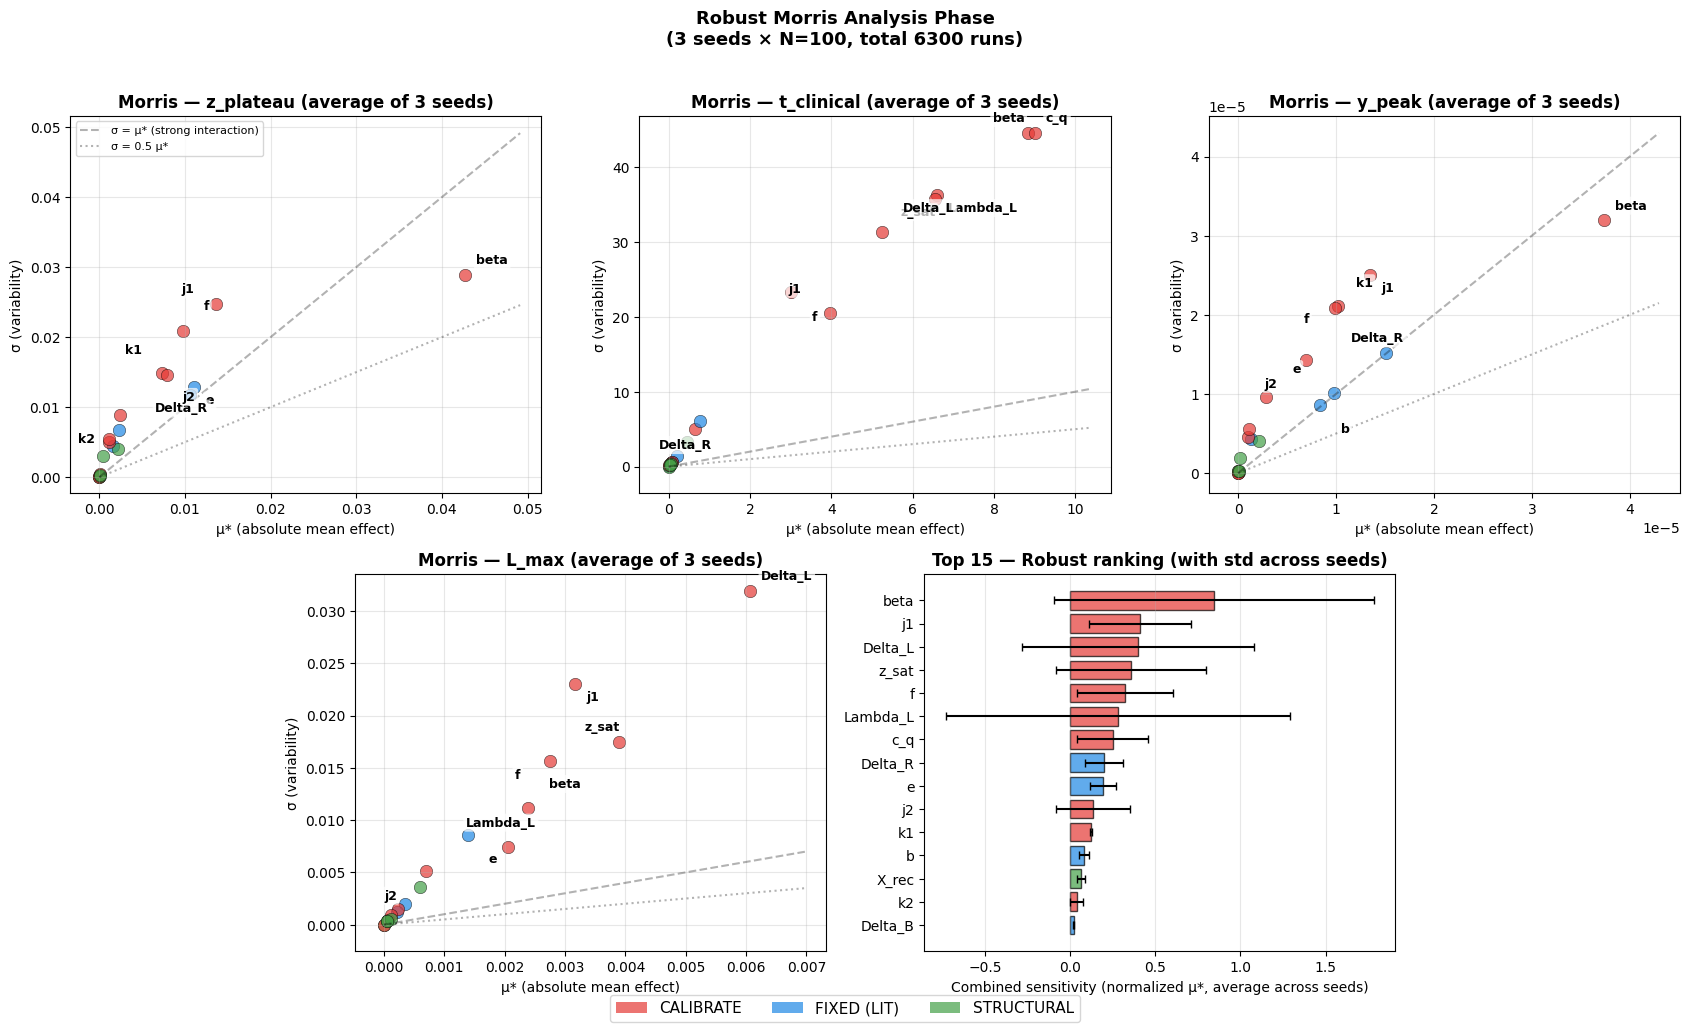

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# 1. Figure configuration and GridSpec (2 rows, 6 columns)
fig = plt.figure(figsize=(17, 10))
gs = gridspec.GridSpec(2, 6, figure=fig)

# 2. Allocation of spaces for each subplot
ax0 = fig.add_subplot(gs[0, 0:2]) # Top row, left
ax1 = fig.add_subplot(gs[0, 2:4]) # Top row, center
ax2 = fig.add_subplot(gs[0, 4:6]) # Top row, right
ax3 = fig.add_subplot(gs[1, 1:3]) # Bottom row, left (centered)
ax4 = fig.add_subplot(gs[1, 3:5]) # Bottom row, right (centered)

# Group axes into a flat list for easy iteration
axes = [ax0, ax1, ax2, ax3, ax4]

# Note: Dictionary keys are kept as-is to match the dataframe's columns
colors_class = {'CALIBRAR':'#E53935', 'FIJO LIT':'#1E88E5', 'ESTRUCT':'#43A047'}
classes = tabla['class'].values

def place_labels(ax, names, mu, sig, top_n=8):
    """Places labels with hierarchical offsets to avoid overlaps."""
    order = np.argsort(-mu)
    # Rotating offsets every 4 labels to distribute them
    offset_patterns = [(8, 8), (-25, 8), (8, -12), (-25, -12),
                       (15, 15), (-30, 15), (15, -20), (-30, -20)]
    for rank, idx in enumerate(order[:top_n]):
        dx, dy = offset_patterns[rank % len(offset_patterns)]
        ax.annotate(names[idx], (mu[idx], sig[idx]),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white', alpha=0.7, edgecolor='none'))

# Panels 0-3: scatter μ* vs σ per observable (average across seeds)
# Now we iterate directly over the axes list
for k, obs in enumerate(observables):
    ax = axes[k]
    mu  = mu_avg[obs]
    sig = sig_avg[obs]

    for i in range(len(problem['names'])):
        ax.scatter(mu[i], sig[i], color=colors_class[classes[i]],
                   s=80, alpha=0.7, edgecolor='black', linewidth=0.4)

    place_labels(ax, problem['names'], mu, sig, top_n=8)

    mu_max = max(mu.max(), 1e-12)
    xx = np.linspace(0, mu_max * 1.15, 50)
    ax.plot(xx, xx,     'k--', alpha=0.3, label='σ = μ* (strong interaction)')
    ax.plot(xx, 0.5*xx, 'k:',  alpha=0.3, label='σ = 0.5 μ*')
    ax.set_xlabel('μ* (absolute mean effect)')
    ax.set_ylabel('σ (variability)')
    ax.set_title(f'Morris — {obs} (average of 3 seeds)', fontweight='bold')
    if k == 0:
        ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
    # Extra margin so labels are not cut off
    ax.set_xlim(left=-mu_max*0.08)
    ax.set_ylim(bottom=-sig.max()*0.08)


# Panel 4: ranking with error bars (std across seeds)
# (No longer need an empty panel, we directly assign the last axis)
ax = axes[4]
top = summary.head(15)
ypos = np.arange(len(top))

# Calculate error of combined sensitivity (propagated from the 4 observables)
err_combined = top[[f'mu_star_{o}_std' for o in observables]].mean(axis=1) \
               / max(summary['combined_sensitivity'].max(), 1e-12)

ax.barh(ypos, top['combined_sensitivity'],
        xerr=err_combined, capsize=3,
        color=[colors_class[c] for c in top['class_']],
        alpha=0.7, edgecolor='black')
ax.set_yticks(ypos)
ax.set_yticklabels(top['parameter'])
ax.invert_yaxis()
ax.set_xlabel('Combined sensitivity (normalized μ*, average across seeds)')
ax.set_title('Top 15 — Robust ranking (with std across seeds)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# English labels applied here for the chart legend
fig.legend(handles=[
    mpatches.Patch(facecolor='#E53935', alpha=0.7, label='CALIBRATE'),
    mpatches.Patch(facecolor='#1E88E5', alpha=0.7, label='FIXED (LIT)'),
    mpatches.Patch(facecolor='#43A047', alpha=0.7, label='STRUCTURAL'),
], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)

n_total_runs = 3 * N_TRAJ * 21
plt.suptitle(f'Robust Morris Analysis Phase\n'
             f'({len(SEEDS)} seeds × N={N_TRAJ}, total {n_total_runs} runs)',
             fontsize=13, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig(OUTDIR / "fase_e_morris.png", dpi=130, bbox_inches='tight')
plt.show()

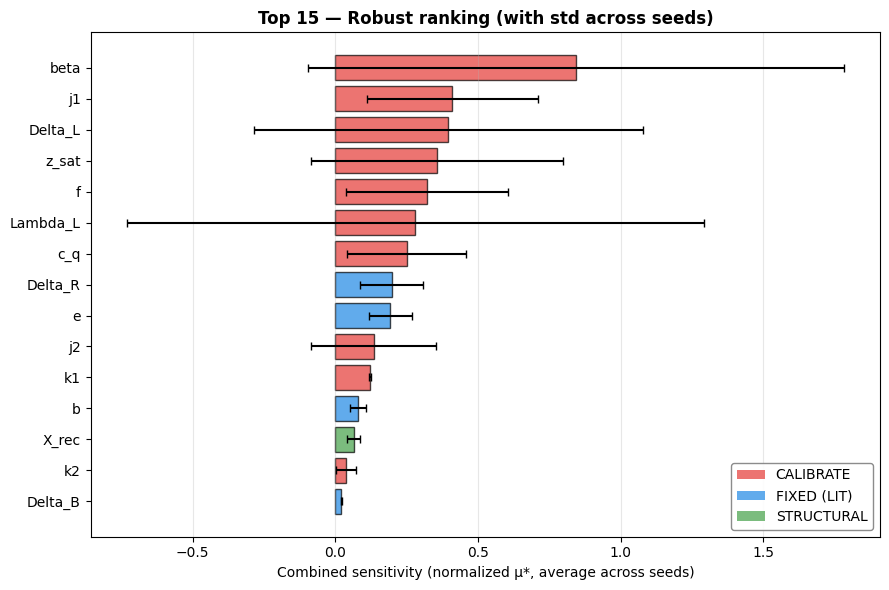

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Single-figure configuration
fig, ax = plt.subplots(figsize=(9, 6))

# Data preparation (top 15)
top = summary.head(15)
ypos = np.arange(len(top))

# Combined-sensitivity error computation
err_combined = top[[f'mu_star_{o}_std' for o in observables]].mean(axis=1) \
               / max(summary['combined_sensitivity'].max(), 1e-12)

# Color mapping (dataframe keys kept as-is)
colors_class = {'CALIBRAR':'#E53935', 'FIJO LIT':'#1E88E5', 'ESTRUCT':'#43A047'}

# Horizontal bar chart creation
ax.barh(ypos, top['combined_sensitivity'],
        xerr=err_combined, capsize=3,
        color=[colors_class[c] for c in top['class_']],
        alpha=0.7, edgecolor='black')

# Axis adjustments
ax.set_yticks(ypos)
ax.set_yticklabels(top['parameter'])
ax.invert_yaxis() # Invert so the most important one is at the top
ax.set_xlabel('Combined sensitivity (normalized μ*, average across seeds)')
ax.set_title('Top 15 — Robust ranking (with std across seeds)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Custom legend
legend_patches = [
    mpatches.Patch(facecolor='#E53935', alpha=0.7, label='CALIBRATE'),
    mpatches.Patch(facecolor='#1E88E5', alpha=0.7, label='FIXED (LIT)'),
    mpatches.Patch(facecolor='#43A047', alpha=0.7, label='STRUCTURAL'),
]
# Placed in the lower-right corner to avoid covering the top bars
ax.legend(handles=legend_patches, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='gray')

# Render and save
plt.tight_layout()
# Make sure OUTDIR is defined in your environment, e.g.: OUTDIR = Path("resultados")
# plt.savefig(OUTDIR / "ranking_morris_aislado.png", dpi=130, bbox_inches='tight')
plt.show()

**Methodological note:** initially, Morris was considered as the sole method for sensitivity and identifiability analysis. However, since it is a global *screening* that does not capture local relationships between parameters, **SVD with Monte Carlo** over the sensitivity matrix was additionally incorporated, allowing both results to be contrasted and providing stronger support for the decision of which parameters to fix and which to calibrate.